<a href="https://colab.research.google.com/github/arya-arun-123/Blood_Cell_Classification_Model/blob/main/PCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import  classification_report,confusion_matrix

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# READ DATASET

In [3]:
# dataset
filepath= "/content/drive/MyDrive/AI  and ML/DataSets/PBC_dataset_normal_DIB"

IMG_SIZE = 224

BATCH_SIZE = 32
EPOCH = 20
SEED = 42


In [4]:
classes = sorted(os.listdir(filepath))

print("Classes Found:\n")

for cls in classes:
    class_path = os.path.join(filepath, cls)

    if os.path.isdir(class_path):

        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{cls:<15} : {len(images)} images")

Classes Found:

basophil        : 1218 images
eosinophil      : 3117 images
erythroblast    : 1551 images
ig              : 2895 images
lymphocyte      : 1214 images
monocyte        : 1420 images
neutrophil      : 3329 images
platelet        : 2348 images


# CREATING TRAINING AND TESTING DATASET

In [5]:
# TRAINING DATASET
# 70 % used for training

train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    shuffle=True
)

Found 17092 files belonging to 8 classes.
Using 11965 files for training.


In [6]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 17092 files belonging to 8 classes.
Using 5127 files for validation.


In [7]:
# VALIDATION AND TEST DATASET
# 15 % - validation datset
# 15 % - testing dataset
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

# AUTO TUNING

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# This allows to load next batch while training current batch

# AUGMENTATION

In [9]:
# Makes changes in training data to prevent overfitting and improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10)
])

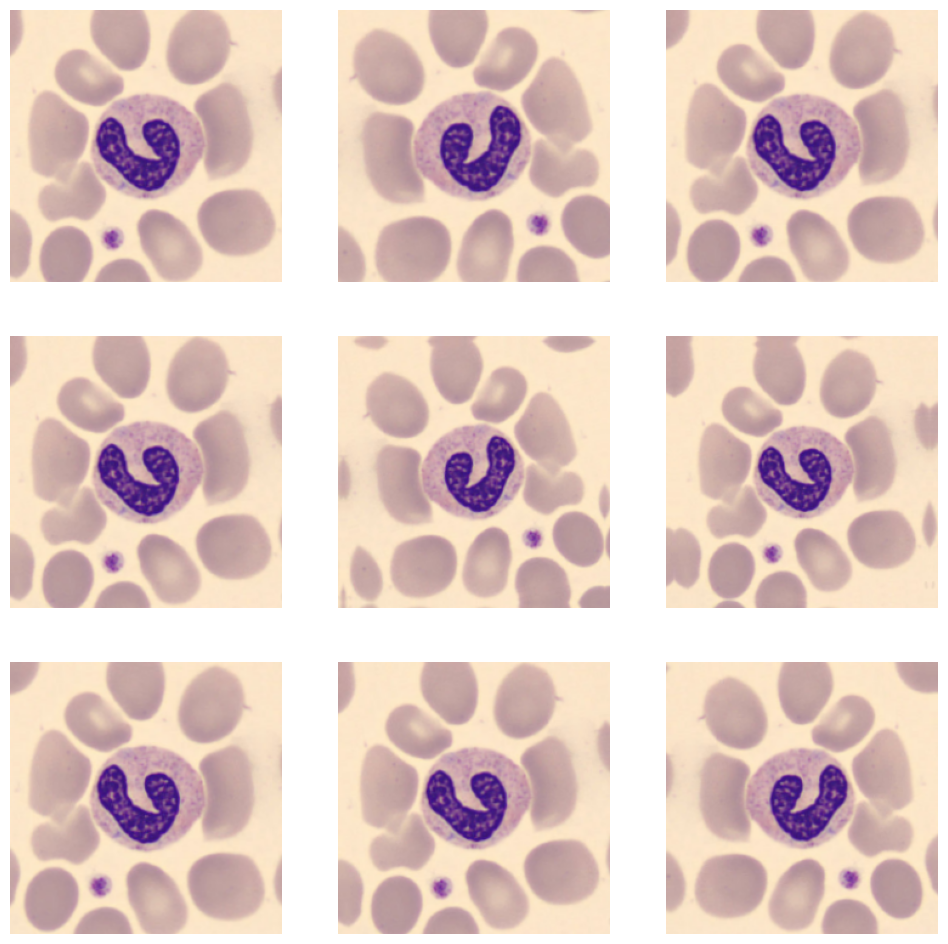

In [10]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.figure(figsize=(12, 12))

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        plt.imshow(augmented_image[0].numpy().astype("uint8"))

        plt.axis("off")

plt.show()

# NORMALIZATION

In [11]:
normalization_layer = layers.Rescaling(1./255)

# MODEL BUILDING

In [12]:
cnn_model = tf.keras.Sequential([


    data_augmentation,
    normalization_layer,
    # LAYER 1
    layers.Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # LAYER 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # LAYER 3
    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.30),

    # OUTPUT LAYER
    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.50),

    layers.Dense(8, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILING THE MODEL

In [13]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CALLBACKS

In [14]:
# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
# Checkpointing
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [16]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Deleting bad file


In [17]:
# the model training kept running into error because of these bad files

# finding the bad files
bad_files = []

for root, _, files in os.walk(filepath):
    for file in files:
        full_path = os.path.join(root, file)

        try:
            with Image.open(full_path) as img:
                img.verify()
        except Exception:
            bad_files.append(full_path)

print("Bad files found:", len(bad_files))

for file in bad_files:
    print(file)

Bad files found: 0


In [18]:
# deleting those bad files
bad_file = "/content/drive/MyDrive/AI  and ML/DataSets/PBC_dataset_normal_DIB/neutrophil/.DS_169665.jpg"

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Deleted:", bad_file)
else:
    print("File not found.")

File not found.


# Recreate the datasets

In [19]:
import tensorflow as tf

# Dataset path
filepath = "/content/drive/MyDrive/AI  and ML/DataSets/PBC_dataset_normal_DIB"

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Create training and validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Datasets recreated successfully!")

Found 17092 files belonging to 8 classes.
Using 13674 files for training.
Found 17092 files belonging to 8 classes.
Using 3418 files for validation.
✅ Datasets recreated successfully!


# MODEL TRAINING

In [20]:
history = cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 91s 197ms/step - accuracy: 0.3337 - loss: 3.2027 - val_accuracy: 0.2952 - val_loss: 35.7471
Epoch 2/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 81s 189ms/step - accuracy: 0.3953 - loss: 1.6760 - val_accuracy: 0.7534 - val_loss: 0.5602
Epoch 3/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 82s 192ms/step - accuracy: 0.3597 - loss: 1.6739 - val_accuracy: 0.9014 - val_loss: 0.4182
Epoch 4/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 81s 188ms/step - accuracy: 0.3788 - loss: 1.6202 - val_accuracy: 0.0000e+00 - val_loss: 151.5506
Epoch 5/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 80s 186ms/step - accuracy: 0.4368 - loss: 1.5037 - val_accuracy: 0.0000e+00 - val_loss: 616.3751


# VGG


## Load the Pre-trained VGG16 Model

In [21]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

## Freeze the VGG model

In [22]:
base_model.trainable = False

## Building new model

In [23]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,564,360 (105.15 MB)

 Trainable params: 12,849,672 (49.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile the model

In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train the model

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 138s 283ms/step - accuracy: 0.5093 - loss: 2.5635 - val_accuracy: 0.9661 - val_loss: 0.1350
Epoch 2/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 99s 231ms/step - accuracy: 0.7108 - loss: 0.8308 - val_accuracy: 0.9781 - val_loss: 0.0806
Epoch 3/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 99s 231ms/step - accuracy: 0.7998 - loss: 0.5694 - val_accuracy: 0.9801 - val_loss: 0.0706
Epoch 4/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 99s 231ms/step - accuracy: 0.8410 - loss: 0.4516 - val_accuracy: 0.9909 - val_loss: 0.0258
Epoch 5/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 140s 228ms/step - accuracy: 0.8706 - loss: 0.3631 - val_accuracy: 0.9898 - val_loss: 0.0353


## Evaluate the model

In [27]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.9909 - loss: 0.0258
Validation Loss: 0.02582869492471218
Validation Accuracy: 0.9909303784370422


## Prediction

In [28]:
predictions = model.predict(val_ds)
predicted_class = np.argmax(predictions[0])

print(predicted_class)

107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step
6


## Save the model


In [29]:
model.save("vgg16_pcb.keras")